# Figuring Out What is Wrong with the Value Function

Plot two checkpoints to check if any training occurs.

In [40]:
PATH = '../../scratch/aorl2/2026-04-03-01/2026-04-03-01.e41dc59d520a81aab8c1bbc9a7e37bef9d23933c1c815333d0945caf62e4dd45/'
FIRST_CKPT_NUM = 800000
SECOND_CKPT_NUM = 900000

Are the checkpoints even correct? Am I mising FQL and GCFQL parameters?

**Yes. Doesn't load properly if different types.**

In [41]:
import json
import os

import numpy as np

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset
from utils.flax_utils import restore_agent

In [42]:
flags_path = os.path.join(PATH, 'flags.json')
with open(flags_path, 'r') as f:
    saved_flags = json.load(f)

agent_config = saved_flags['agent']
dataset_class_name = saved_flags.get('dataset_class', 'GCDataset')
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
}[dataset_class_name]

dataset_path = os.path.join(PATH, 'data-1000000.npz')
dataset_npz = np.load(dataset_path)
train_dataset = dataset_class(Dataset.create(**dict(dataset_npz)), config=agent_config)

seed = saved_flags.get('seed', 0)
example_batch = train_dataset.sample(1)

first_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
first_agent = restore_agent(first_agent, PATH, FIRST_CKPT_NUM)

second_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
second_agent = restore_agent(second_agent, PATH, SECOND_CKPT_NUM)

print(f'Restored first_agent from checkpoint {FIRST_CKPT_NUM}')
print(f'Restored second_agent from checkpoint {SECOND_CKPT_NUM}')

Restored from ../../scratch/aorl2/2026-04-03-01/2026-04-03-01.e41dc59d520a81aab8c1bbc9a7e37bef9d23933c1c815333d0945caf62e4dd45//params_800000.pkl
Restored from ../../scratch/aorl2/2026-04-03-01/2026-04-03-01.e41dc59d520a81aab8c1bbc9a7e37bef9d23933c1c815333d0945caf62e4dd45//params_900000.pkl
Restored first_agent from checkpoint 800000
Restored second_agent from checkpoint 900000


In [43]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

  5%|▍         | 90948/2000000 [00:00<00:10, 180599.73it/s]

100%|██████████| 2000000/2000000 [00:11<00:00, 180628.19it/s]


In [44]:
goal = np.asarray([10, 15])

In [45]:
all_goals = np.repeat(goal[None], len(all_cell_points), axis=0)
all_vs = first_agent.network.select('value')(all_cell_points, all_goals)

In [46]:
import matplotlib.pyplot as plt

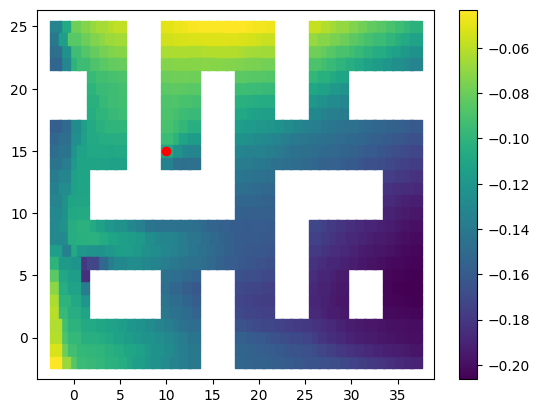

In [47]:
m = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=68, marker='s', c=all_vs, cmap='viridis')
plt.scatter(x=goal[0], y=goal[1], c='red')
plt.colorbar(m)
plt.show()

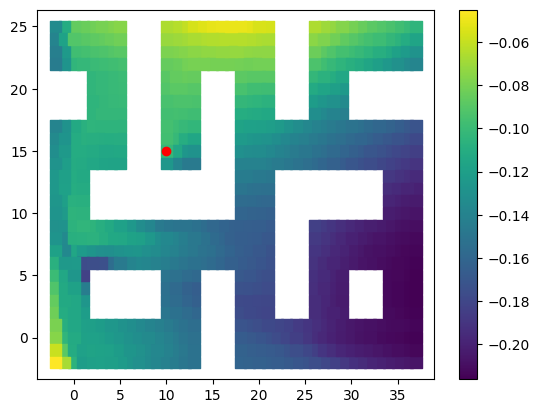

In [48]:
all_goals = np.repeat(goal[None], len(all_cell_points), axis=0)
all_vs = second_agent.network.select('value')(all_cell_points, all_goals)

m = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=68, marker='s', c=all_vs, cmap='viridis')
plt.scatter(x=goal[0], y=goal[1], c='red')
plt.colorbar(m)
plt.show()

In [49]:
first_agent.network.params.keys()

dict_keys(['modules_critic', 'modules_target_critic', 'modules_value', 'modules_actor_bc_flow', 'modules_actor_onestep_flow', 'modules_goal_proposer'])

In [64]:
first_value_params = first_agent.network.params['modules_value']
second_value_params = second_agent.network.params['modules_value']


In [65]:
import jax

jax.tree_util.tree_map(lambda x: x.shape, first_value_params)


{'value_net': {'Dense_0': {'bias': (512,), 'kernel': (4, 512)},
  'Dense_1': {'bias': (512,), 'kernel': (512, 512)},
  'Dense_2': {'bias': (512,), 'kernel': (512, 512)},
  'Dense_3': {'bias': (512,), 'kernel': (512, 512)},
  'Dense_4': {'bias': (1,), 'kernel': (512, 1)},
  'LayerNorm_0': {'bias': (512,), 'scale': (512,)},
  'LayerNorm_1': {'bias': (512,), 'scale': (512,)},
  'LayerNorm_2': {'bias': (512,), 'scale': (512,)},
  'LayerNorm_3': {'bias': (512,), 'scale': (512,)}}}

In [66]:
import numpy as np

first_value_weights = jax.tree_util.tree_map(np.array, first_value_params)
second_value_weights = jax.tree_util.tree_map(np.array, second_value_params)


In [67]:
first_value_weights

{'value_net': {'Dense_0': {'bias': array([ 1.32822275e-01,  2.93836951e-01,  5.23023546e-01,  5.16772389e-01,
           2.42501095e-01,  3.82005125e-01,  2.26092190e-01,  5.98085448e-02,
           3.18209171e-01,  5.28039455e-01,  3.43063742e-01,  4.13731307e-01,
          -7.36961141e-02,  9.35058355e-01,  3.01046968e-01,  6.82941616e-01,
          -1.00881875e+00,  3.89661491e-01, -3.97257000e-01, -7.60854483e-01,
           7.92535126e-01,  2.94311404e-01,  1.13792852e-01,  1.64107293e-01,
           1.36141583e-01,  6.21491559e-02,  3.38787258e-01,  3.02328497e-01,
           9.87283349e-01,  3.92981559e-01,  2.19098672e-01,  2.63273805e-01,
           2.54663050e-01,  3.77985507e-01,  4.41587418e-01,  2.29797199e-01,
           3.96632612e-01,  2.55461454e-01,  4.89619374e-01,  5.80051959e-01,
           5.88162184e-01, -1.12557039e-01,  2.38284692e-01,  9.92123485e-01,
          -3.19342732e-01,  5.17129660e-01, -7.70822465e-01,  1.12644136e+00,
           2.26105198e-01,  2.94

In [68]:
second_value_weights

{'value_net': {'Dense_0': {'bias': array([ 2.21686617e-01,  3.09549004e-01,  5.88768423e-01,  5.42883337e-01,
           2.53437042e-01,  4.23297256e-01,  1.46853164e-01,  3.04333922e-02,
           3.29993278e-01,  5.51173210e-01,  3.74195457e-01,  4.31022674e-01,
          -7.09728524e-02,  9.99469638e-01,  3.14316154e-01,  7.33226955e-01,
          -1.03631258e+00,  4.10671800e-01, -4.26726609e-01, -7.71833241e-01,
           8.72799695e-01,  3.12511533e-01,  1.45975277e-01,  1.23961322e-01,
           1.77699253e-01,  9.11422223e-02,  3.61047536e-01,  3.23529929e-01,
           1.03262818e+00,  4.35244590e-01,  2.55377173e-01,  2.85478145e-01,
           2.53828228e-01,  4.10183907e-01,  4.73501444e-01,  2.60666013e-01,
           4.32095796e-01,  2.43573904e-01,  5.22673428e-01,  6.03884101e-01,
           6.15046859e-01, -1.05512746e-01,  2.61726499e-01,  1.01942933e+00,
          -3.07055593e-01,  5.47175527e-01, -6.94632769e-01,  1.16719496e+00,
           2.49171942e-01,  3.09

In [70]:
(first_value_weights['value_net']['Dense_0']['bias'] == second_value_weights['value_net']['Dense_0']['bias'])

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [73]:
train_dataset.dataset['observations'][..., :2]

array([[-0.07952569,  8.261749  ],
       [-0.07690136,  8.260354  ],
       [-0.07960749,  8.264774  ],
       ...,
       [-0.3887374 , 17.31017   ],
       [-0.36054185, 17.32144   ],
       [-0.33091882, 17.322565  ]], dtype=float32)

In [72]:
train_dataset.dataset['oracle_reps']

array([[-0.07952569,  8.261749  ],
       [-0.07690136,  8.260354  ],
       [-0.07960749,  8.264774  ],
       ...,
       [-0.3887374 , 17.31017   ],
       [-0.36054185, 17.32144   ],
       [-0.33091882, 17.322565  ]], dtype=float32)

In [74]:
(train_dataset.dataset['observations'][..., :2] == train_dataset.dataset['oracle_reps']).all()

True